In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import re

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV


In [2]:
ed = pd.read_excel('/Users/elysa/Downloads/DAT 490 EDA Sheets Combined.xlsx', sheet_name = "2021 ED Combo Data")

In [3]:
ed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4272 entries, 0 to 4271
Columns: 189 entries, oshpd_id to ed_STATIONS_ON_1231
dtypes: float64(163), int64(3), object(23)
memory usage: 6.2+ MB


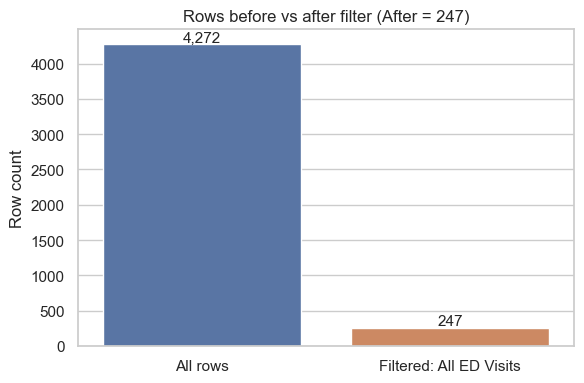

In [4]:
#filter to all visits"
mask_all = ed["Category"].eq("All ED Visits")
n_before = ed.shape[0]
n_after  = ed.loc[mask_all].shape[0]   

# plot before and after filter
plot_fac = pd.DataFrame({"Stage": ["All rows", "Filtered: All ED Visits"], "Count": [n_before, n_after]})

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=plot_fac, x="Stage", y="Count", ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Row count")
ax.set_title(f"Rows before vs after filter (After = {n_after:,})")

# label bars
for p, v in zip(ax.patches, plot_fac["Count"]):
    ax.annotate(f"{v:,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

In [5]:
ed = ed[ed["Category"] == "All ED Visits"]

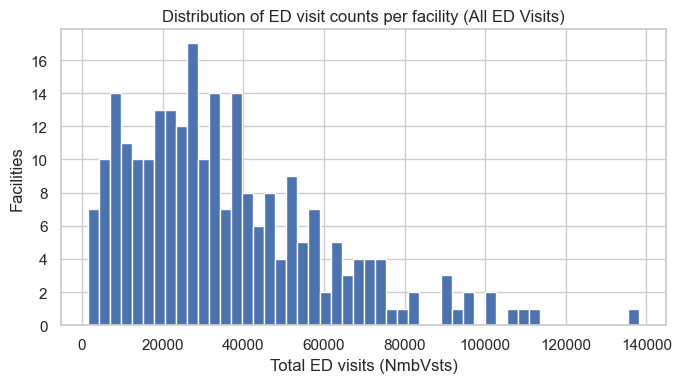

In [6]:
# Histogram of facility visit counts
plt.figure(figsize=(7,4))
plt.hist(ed["NmbVsts"].dropna(), bins=50)
plt.title("Distribution of ED visit counts per facility (All ED Visits)")
plt.xlabel("Total ED visits (NmbVsts)"); plt.ylabel("Facilities")
plt.tight_layout(); plt.show()


In [7]:
ed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 1 to 493
Columns: 189 entries, oshpd_id to ed_STATIONS_ON_1231
dtypes: float64(163), int64(3), object(23)
memory usage: 366.6+ KB


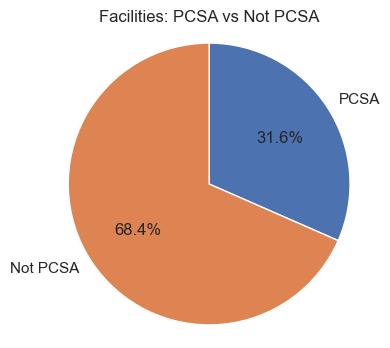

In [8]:
# Clean labels and get counts
pcsas = (ed["PrimaryCareShortageArea"].astype(str).map({"Yes":"PCSA", "No":"Not PCSA"}))
counts = pcsas.value_counts().reindex(["PCSA","Not PCSA"]).dropna()

# Pie chart
fig, ax = plt.subplots(figsize=(4,4))
ax.pie(counts.values,labels=counts.index, autopct=lambda p: f"{p:.1f}%", startangle=90, counterclock=False)
ax.axis("equal")  
ax.set_title("Facilities: PCSA vs Not PCSA")
plt.show()

In [9]:
# Paste cols from Excel Sheet
raw_cols = r"""
disp_Acute_Care disp_Against_Medical_Advice disp_Childrens_or_Cancer disp_Died
disp_Home_Health_Service disp_Invalid_Blank disp_Not_Defined_Elsewhere
disp_Prison_Jail disp_Psychiatric_Care disp_Residential_Care disp_Routine
disp_SN_IC_Care Medi_Cal Medicare Other_Payer Private_Coverage SelfPay
Zip_CA_Resident Zip_Foreign Zip_Homeless Zip_Out_of_State Sex_Female Sex_Male
Sex_Other_Unknown Age_0_09 Age_10_19 Age_20_29 Age_30_39 Age_40_49 Age_50_59
Age_60_69 Age_70_79 Age_80_ Age_Other_Unknown racegrp_aman racegrp_asian
racegrp_black racegrp_multirace racegrp_nhpi racegrp_other racegrp_unknown
racegrp_white eth_Hispanic eth_NonHispanic eth_Other_Unknown All_Other_Languages
English PLS_Other_Unknown Spanish dx_Circulatory dx_Digestive
dx_Diseases_of_the_Blood dx_Ear dx_Endocrine dx_Eye dx_Factors_Influencing_Health
dx_Genitourinary dx_Infectious dx_Injury_Poisoning dx_MentalHealth
dx_Musculoskeletal dx_Neoplasms dx_Nervous_System dx_Other_Unknown
dx_Pregnancy_Childbirth dx_Respiratory dx_Skin dx_Symptoms_Signs_NEC
disp_CAH disp_Hospice_Care disp_Rehab Zip_Unknown dx_Certain_Perinatal_Conditions
dx_Congenital disp_Other Zip_Blank_Invalid Unknown_inv_Payer disp_Disaster_Care_Site
a_disp_Acute_Care a_disp_Against_Medical_Advice a_disp_Died a_disp_Home_Health_Service
a_disp_Hospice_Care a_disp_Psychiatric_Care a_disp_Rehab a_disp_Residential_Care
a_disp_Routine a_disp_SN_IC_Care a_Medi_Cal a_Medicare a_Other_Payer a_Private_Coverage
a_SelfPay a_Zip_CA_Resident a_Zip_Foreign a_Zip_Homeless a_Zip_Out_of_State a_Sex_Female
a_Sex_Male a_Age_20_29 a_Age_30_39 a_Age_40_49 a_Age_50_59 a_Age_60_69 a_Age_70_79
a_Age_80_ a_Age_Other_Unknown a_racegrp_asian a_racegrp_black a_racegrp_multirace
a_racegrp_other a_racegrp_unknown a_racegrp_white a_Eth_Other_Unknown a_eth_Hispanic
a_eth_NonHispanic a_All_Other_Languages a_English a_PLS_Other_Unknown a_Spanish
a_dx_Circulatory a_dx_Digestive a_dx_Diseases_of_the_Blood a_dx_Ear a_dx_Endocrine
a_dx_Genitourinary a_dx_Infectious a_dx_Injury_Poisoning a_dx_MentalHealth
a_dx_Musculoskeletal a_dx_Neoplasms a_dx_Nervous_System a_dx_Other_Unknown
a_dx_Respiratory a_dx_Skin a_dx_Symptoms_Signs_NEC a_disp_Childrens_or_Cancer
a_disp_Not_Defined_Elsewhere a_disp_Prison_Jail a_Zip_Unknown a_Age_10_19 a_racegrp_aman
a_racegrp_nhpi a_dx_Congenital a_dx_Eye a_dx_Factors_Influencing_Health
a_dx_Pregnancy_Childbirth a_disp_CAH a_Age_0_09 a_dx_Certain_Perinatal_Condition
a_Zip_Blank_Invalid a_sex_Oth_Unknown a_Unknown_inv_Payer a_disp_Other
a_disp_Invalid_Blank a_disp_Disaster_Care_Site
"""

# Assign columns to col list
count_cols = [c for c in re.split(r"[\s,]+", raw_cols.strip()) if c]

# impute 0s
ed[count_cols] = ed[count_cols].apply(pd.to_numeric, errors="coerce").fillna(0)


In [10]:
# convert counts to proportion of total visits per hospital
prop = ed[count_cols].div(ed["NmbVsts"], axis=0)
prop.columns = [f"prop_{c}" for c in count_cols]

In [11]:
# Attach proportion columns
ed = pd.concat([ed, prop], axis=1)

# Check that sets of per-row proportions add up to 1
def check_group(prefixes):
    cols = [c for c in count_cols if any(c.startswith(p) for p in prefixes)]
    if not cols: 
        return
    s = ed[[f"prop_{c}" for c in cols]].sum(axis=1)
    print(f"{prefixes}: median={s.median():.3f}, IQR=[{s.quantile(0.25):.3f}, {s.quantile(0.75):.3f}]")

check_group(["disp_"])
check_group(["dx_"])
check_group(["Age_"])
check_group(["Sex_"])
check_group(["racegrp_"])
check_group(["eth_"])

['disp_']: median=1.000, IQR=[1.000, 1.000]
['dx_']: median=1.000, IQR=[1.000, 1.000]
['Age_']: median=1.000, IQR=[1.000, 1.000]
['Sex_']: median=1.000, IQR=[1.000, 1.000]
['racegrp_']: median=1.000, IQR=[1.000, 1.000]
['eth_']: median=1.000, IQR=[1.000, 1.000]


In [12]:
#keep only "All ED Visits"
df = ed.copy()
mask_all = df["Category"].astype(str).str.strip().str.lower().eq("all ed visits")
df_fac = df.loc[mask_all].copy()

y = (df_fac["PrimaryCareShortageArea"].astype(str).map({"Yes":1, "No":0}))
keep = y.notna()
df_fac, y = df_fac.loc[keep].copy(), y.loc[keep].astype(int)

# all count features as prop
prop_cols = [c for c in df_fac.columns if c.startswith("prop_")]
cat = ["BedSize", "HospitalOwnership", "TechingDesignation","CONTROL_TYPE_DESC", "ER_SERVICE_LEVEL_DESC" ]
cat_cols = [c for c in cat if c in df_fac.columns]

#VPS is already a proportion of 
num_cols = prop_cols + ["Visits_Per_Station"] 

X = df_fac[num_cols + cat_cols].copy() # append numerical and categorical columns


#Impute missing values and scale
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler(with_mean=False))])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

pre = ColumnTransformer(transformers=[("num", numeric_transformer, num_cols), ("cat", categorical_transformer, cat_cols),],remainder="drop")

In [13]:
# Split data to train and evaluate sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

In [14]:
base_model = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")

pipe = Pipeline(steps=[("pre", pre), ("clf", base_model)])

# Grid search for c hyperparameter
param_grid = {"clf__C": [0.05, 0.1, 0.5, 1, 2], "clf__penalty": ["l2"], "clf__solver": ["lbfgs"], "clf__max_iter": [2000]}     


# CV + ROC-AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
gcv = GridSearchCV(estimator=pipe,param_grid=param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True, verbose=0)

# Fit on on training data
gcv.fit(X_train, y_train)

# Use the best estimator
pipe = gcv.best_estimator_
print("Best params:", gcv.best_params_)
print("CV best ROC AUC:", gcv.best_score_)


Best params: {'clf__C': 0.05, 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
CV best ROC AUC: 0.8133036890645586


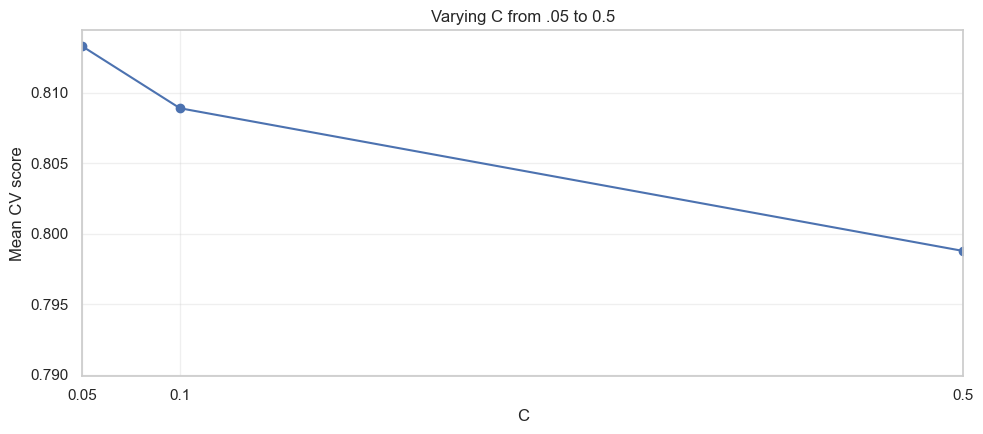

In [15]:
# Plot CV AUC vs C for ligistic
res = gcv.cv_results_
C = np.asarray(res["param_clf__C"], dtype=float)
score = np.asarray(res["mean_test_score"], dtype=float)
order = C.argsort(); C, score = C[order], score[order]
fig, ax = plt.subplots(figsize=(10, 4.5))
plt.plot(C, score, "o-")
plt.xlabel("C")
plt.ylabel("Mean CV score")
plt.title("Varying C from .05 to 0.5")
plt.xticks(C, [f"{c:g}" for c in C])
plt.xlim(0.05, 0.5)   # zoom in
plt.grid(True, alpha=0.3)
plt.tight_layout()



In [16]:
clf = pipe.named_steps["clf"] 
pipe.fit(X_train, y_train)
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f"Accuracy (pipe.score): {pipe.score(X_test, y_test):.3f}")



Accuracy (pipe.score): 0.773


<Figure size 600x500 with 0 Axes>

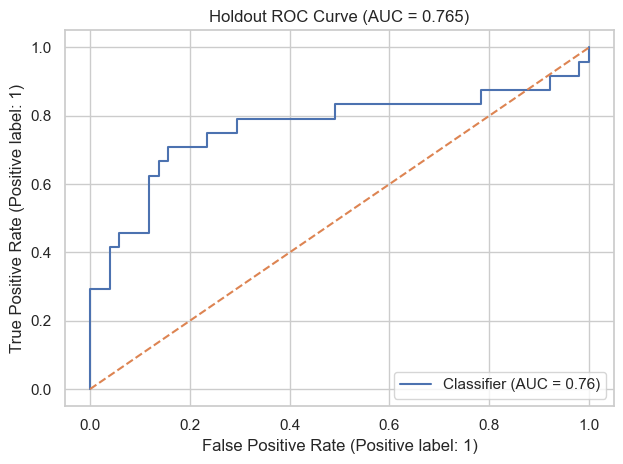

In [17]:
auc_val = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.plot([0, 1], [0, 1], linestyle="--")  # chance line
plt.title(f"Holdout ROC Curve (AUC = {auc_val:.3f})")
plt.tight_layout()
plt.show()


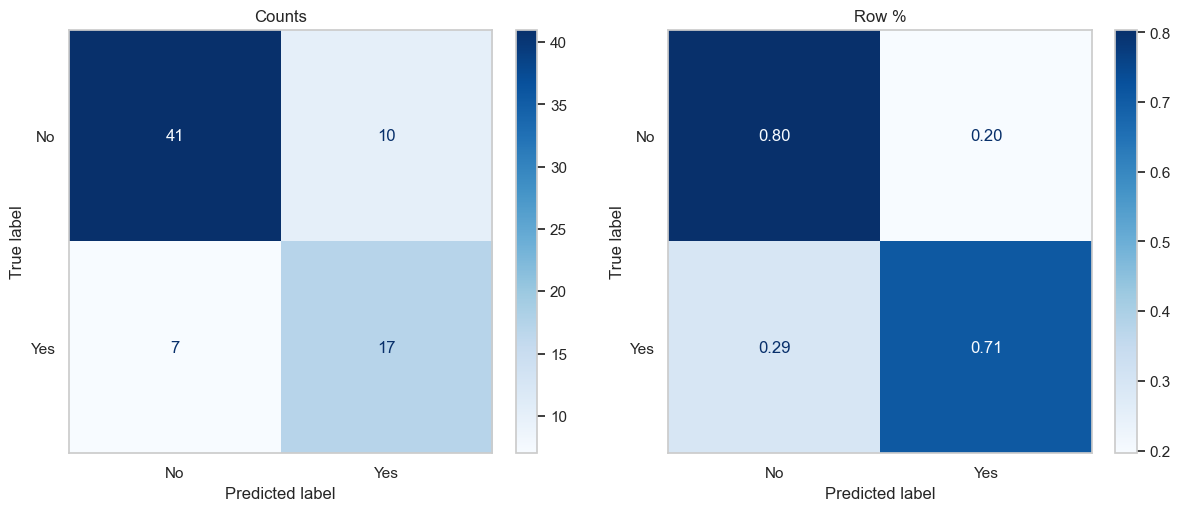

In [18]:
y_pred = (y_prob >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=[0,1], display_labels=["No","Yes"],
    ax=axes[0], cmap="Blues", normalize=None, values_format="d"
)
axes[0].set_title("Counts")
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=[0,1], display_labels=["No","Yes"],
    ax=axes[1], cmap="Blues", normalize="true", values_format=".2f"
)
axes[1].set_title("Row %")
axes[1].grid(False)

plt.show()

In [19]:
sns.set_theme(style="whitegrid")
names = pipe.named_steps["pre"].get_feature_names_out().tolist() #pass from preprocessor
coefs = pd.Series(pipe.named_steps["clf"].coef_.ravel(), index=names) #pass from classifier

In [20]:
# Logistic Regression coefficients top +/- 
def plot_logistic_coefs(pipe, top_n=15):

#Top positive and top negative
    top_pos = coefs.sort_values(ascending=False).head(top_n)
    top_neg = coefs.sort_values(ascending=True).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.35*top_n)))
    sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0])
    axes[0].set_title(f"Top {top_n} positive (→ Shortage = Yes)")
    axes[0].set_xlabel("Coefficient"); axes[0].set_ylabel("")

    sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1])
    axes[1].set_title(f"Top {top_n} negative (→ Shortage = No)")
    axes[1].set_xlabel("Coefficient"); axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

# Single-panel diverging bars by |coef|
    top_abs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(top_n).index)
    plt.figure(figsize=(9, max(4, 0.45*top_n)))
    colors = np.where(top_abs.values > 0, "tab:red", "tab:blue")
    sns.barplot(x=top_abs.values, y=top_abs.index, palette=colors)
    plt.title(f"Logistic Regression: Top {top_n} by |coef|  (red→Yes, blue→No)")
    plt.xlabel("Coefficient"); plt.ylabel("")
    plt.axvline(0, color="k", linewidth=1)
    plt.tight_layout()
    plt.show()


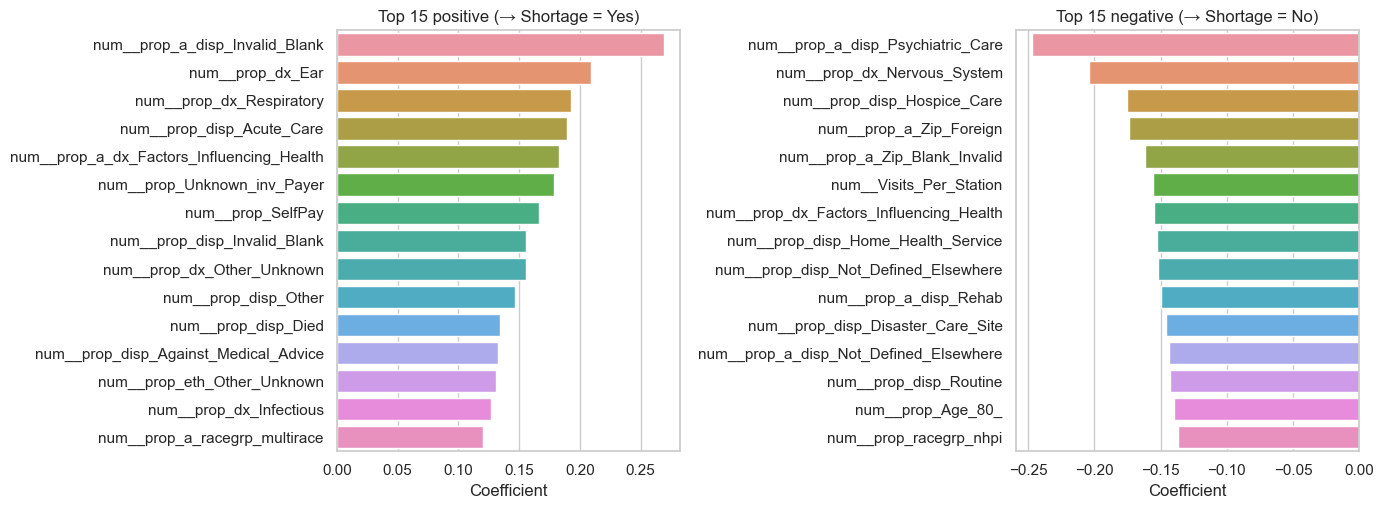

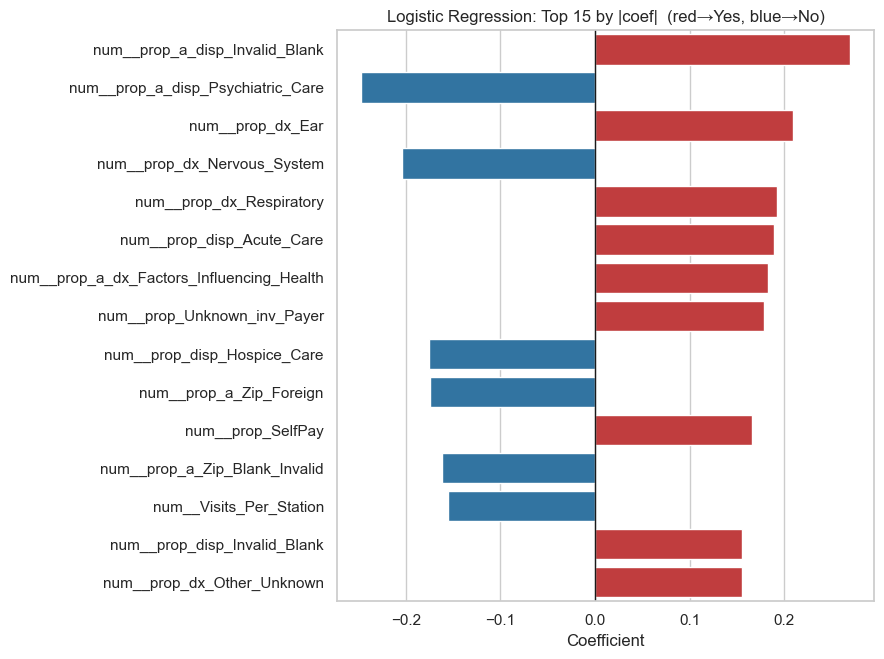

In [21]:
# After training:
plot_logistic_coefs(pipe, top_n=15)


In [22]:
print("Holdout ROC AUC:", roc_auc_score(y_test, y_prob).round(3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

# Cross-validate ROC AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print("CV ROC AUC:", np.round(cv_auc, 3), "mean =", cv_auc.mean().round(3))

# Build feature names 
num_names = num_cols
cat_names = []
if cat_cols:
    ohe = pipe.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
    cat_names = list(ohe.get_feature_names_out(cat_cols))
feature_names = num_names + cat_names

coefs = pd.Series(pipe.named_steps["clf"].coef_.ravel(), index=names).sort_values(key=np.abs, ascending=False)
print("\nTop 20 drivers (|coef|):")
print(coefs.head(20))


Holdout ROC AUC: 0.765
Confusion matrix:
 [[41 10]
 [ 7 17]]

Classification report:
               precision    recall  f1-score   support

           0      0.854     0.804     0.828        51
           1      0.630     0.708     0.667        24

    accuracy                          0.773        75
   macro avg      0.742     0.756     0.747        75
weighted avg      0.782     0.773     0.777        75

CV ROC AUC: [0.801 0.825 0.825 0.88  0.803] mean = 0.827

Top 20 drivers (|coef|):
num__prop_a_disp_Invalid_Blank               0.269162
num__prop_a_disp_Psychiatric_Care           -0.247027
num__prop_dx_Ear                             0.209483
num__prop_dx_Nervous_System                 -0.203871
num__prop_dx_Respiratory                     0.192847
num__prop_disp_Acute_Care                    0.189185
num__prop_a_dx_Factors_Influencing_Health    0.182847
num__prop_Unknown_inv_Payer                  0.178545
num__prop_disp_Hospice_Care                 -0.175205
num__prop_a_Zip_Fo

In [23]:
#Get the numeric columns from the pipeline-the prop_ training set
def expected_raw_columns(pipe):
    return {name: list(cols) if not callable(cols) else [] for name, trans, cols in pre.transformers}

num_cols = expected_raw_columns(pipe)["num"]

# Build counts groups by prefix
def base(c): return c.removeprefix("prop_")
PAYERS = {"Medi_Cal","Medicare","Other_Payer","Private_Coverage","SelfPay","Unknown_inv_Payer"}
LANGS  = {"All_Other_Languages","English","PLS_Other_Unknown","Spanish"}

groups = {
    "disp":    [c for c in num_cols if base(c).startswith(("disp_","a_disp_"))],
    "dx":      [c for c in num_cols if base(c).startswith(("dx_","a_dx_"))],
    "payer":   [c for c in num_cols if base(c) in PAYERS or base(c).startswith(("a_Medi_Cal","a_Medicare","a_Other_Payer","a_Private_Coverage","a_SelfPay","a_Unknown_inv_Payer"))],
    "zip":     [c for c in num_cols if base(c).startswith(("Zip_","a_Zip_"))],
    "sex":     [c for c in num_cols if base(c).startswith(("Sex_","a_Sex_")) or base(c) in {"a_sex_Oth_Unknown"}],
    "age":     [c for c in num_cols if base(c).startswith(("Age_","a_Age_"))],
    "race":    [c for c in num_cols if base(c).startswith(("racegrp_","a_racegrp_"))],
    "eth":     [c for c in num_cols if base(c).startswith(("eth_","a_eth_")) or base(c) in {"a_Eth_Other_Unknown"}],
    "lang":    [c for c in num_cols if base(c) in LANGS or base(c).startswith(("a_All_Other_Languages","a_English","a_PLS_Other_Unknown","a_Spanish"))],
    "unknown": [c for c in num_cols if base(c) in {"Zip_Blank_Invalid","disp_Invalid_Blank"}],
}

In [24]:
#Group permutation importance with 95% CIs, using the fitted pipe
def group_perm_importance(pipe, X_test, y_test, groups_dict, n_repeats=200, seed=0):
    rng = np.random.default_rng(seed)
    base_auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])
    rows = []
    for g, cols in groups_dict.items():
        cols = [c for c in cols if c in X_test.columns]
        if not cols:
            continue
        drops = []
        for _ in range(n_repeats):
            Xt = X_test.copy()
            # permute every column in the group
            for c in cols:
                Xt[c] = rng.permutation(Xt[c].values)
            auc = roc_auc_score(y_test, pipe.predict_proba(Xt)[:,1])
            drops.append(base_auc - auc)
        lo, hi = np.percentile(drops, [2.5, 97.5])
        rows.append({"group": g, "mean_drop": float(np.mean(drops)), "ci_lo": float(lo), "ci_hi": float(hi),
                     "n_cols": len(cols)})
    return pd.DataFrame(rows).sort_values("mean_drop", ascending=False)

gp_perm = group_perm_importance(pipe, X_test, y_test, groups, n_repeats=200)
print(gp_perm)

     group  mean_drop     ci_lo     ci_hi  n_cols
0     disp   0.091560  0.013051  0.170997      34
6     race   0.027851  0.003268  0.053105      16
3      zip   0.021969 -0.000837  0.041708      12
4      sex   0.009551 -0.004085  0.025327       6
7      eth   0.008468 -0.002451  0.018811       6
5      age   0.005989 -0.023754  0.024530      20
8     lang   0.004959 -0.004085  0.016381       8
1       dx   0.004734 -0.033538  0.039318      42
9  unknown   0.001520 -0.019669  0.021242       2
2    payer   0.000053 -0.025347  0.022100      12


In [25]:
def group_perm_distributions(pipe, X_test, y_test, groups, n_repeats=200, seed=0):
# Return dict: groups AUC drops from permuting that group's columns.
    rng = np.random.default_rng(seed)
    base_auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])
    dist = {}
    for g, cols in groups.items():
        cols = [c for c in cols if c in X_test.columns]
        if not cols:
            continue
        drops = []
        for _ in range(n_repeats):
            Xt = X_test.copy()
            for c in cols:
                Xt[c] = rng.permutation(Xt[c].values)
            auc = roc_auc_score(y_test, pipe.predict_proba(Xt)[:,1])
            drops.append(base_auc - auc)
        dist[g] = np.asarray(drops)
    return dist


/var/folders/7g/gblq5dw54b98ghbc1w_djjfm0000gn/T/ipykernel_43989/4024166531.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=labels, whis=(2.5,97.5), showfliers=False)


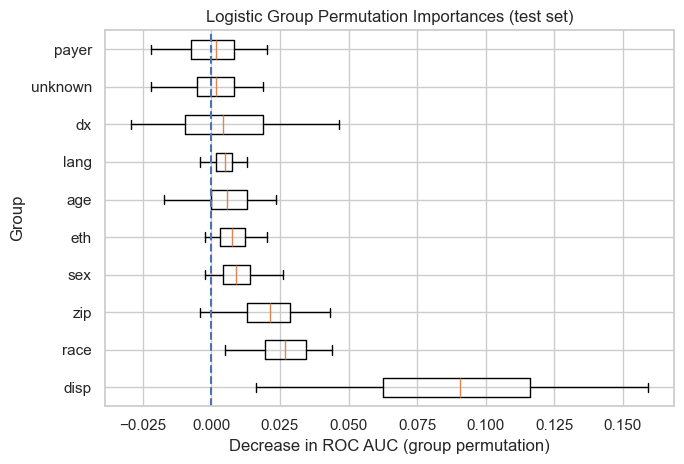

In [26]:

# Plot distribution of AUC drops
def plot_group_perm_boxplots(dist, top_k=None, title= f"Logistic Group Permutation Importances (test set)"):
    """Plot horizontal boxplots from group->array distributions."""
    if not dist:
        raise ValueError("No group distributions to plot (check your groups and X_test columns).")
    # order by mean drop
    items = sorted(dist.items(), key=lambda kv: kv[1].mean(), reverse=True)
    if top_k:
        items = items[:top_k]
    labels = [k for k,_ in items]
    data   = [v for _,v in items]

    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.boxplot(data, vert=False, labels=labels, whis=(2.5,97.5), showfliers=False)
    ax.axvline(0, linestyle="--")
    ax.set_xlabel("Decrease in ROC AUC (group permutation)")
    ax.set_ylabel("Group")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

dist = group_perm_distributions(pipe, X_test, y_test, groups, n_repeats=200, seed=1)
plot_group_perm_boxplots(dist, top_k=None)  


In [27]:
# Using disposition per visit columns only
disp_cols = sorted([c for c in X_train.columns if c.startswith("prop_disp_")])

In [28]:

# Preprocess only disposition columns as numeric counts
pre_disp = ColumnTransformer(transformers=[("num", StandardScaler(with_mean=False), disp_cols)], remainder="drop")

# default logistic for coefficients
clf_disp = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")

pipe_disp = Pipeline(steps=[("pre", pre_disp), ("clf", clf_disp)])

# Subset disposition columns
pipe_disp.fit(X_train[disp_cols], y_train)

# Evaluate
from sklearn.metrics import roc_auc_score
y_prob_disp = pipe_disp.predict_proba(X_test[disp_cols])[:, 1]
print("Dispositions-only ROC AUC:", roc_auc_score(y_test, y_prob_disp).round(3))


Dispositions-only ROC AUC: 0.758


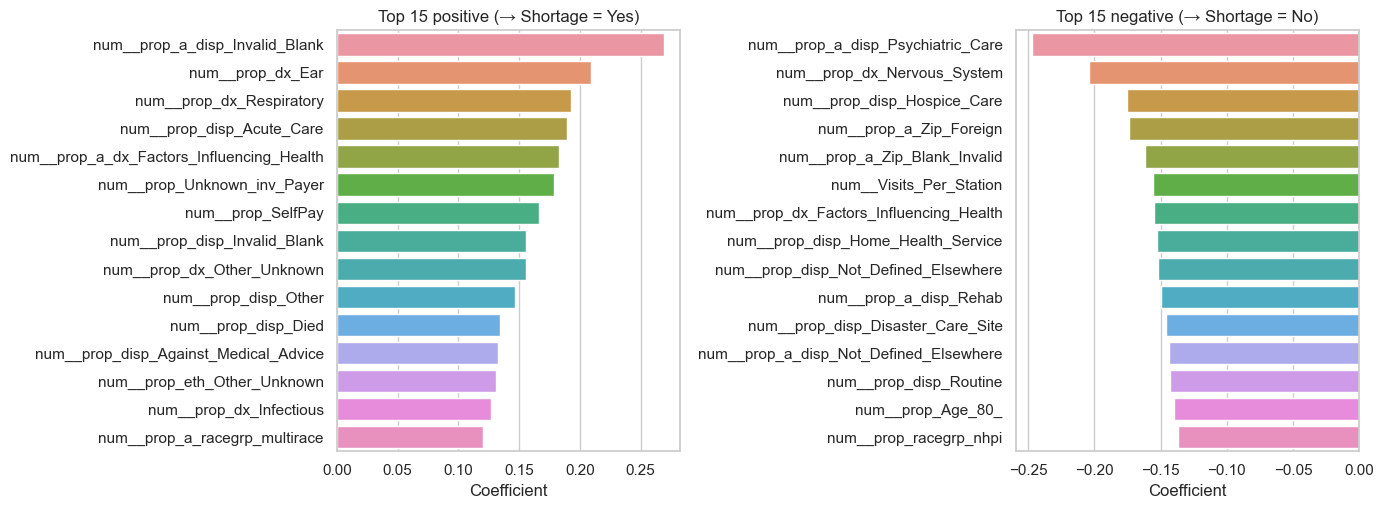

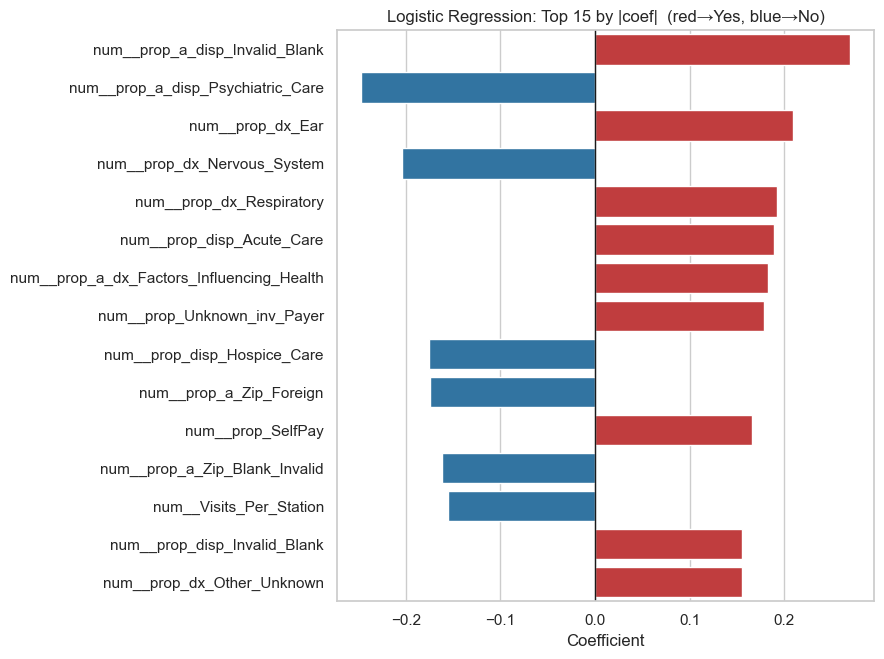

Accuracy (pipe_disp.score): 0.707


In [29]:
plot_logistic_coefs(pipe_disp, top_n=15)

print(f"Accuracy (pipe_disp.score): {pipe_disp.score(X_test, y_test):.3f}")

In [30]:
#computed on the training set
corr_s = X_train[disp_cols].corrwith(y_train.astype(int)).sort_values(ascending=False)
print("Correlation with PCSA (train):\n", corr_s)


Correlation with PCSA (train):
 prop_disp_Acute_Care                0.418585
prop_disp_CAH                       0.244525
prop_disp_Prison_Jail               0.242800
prop_disp_Against_Medical_Advice    0.193753
prop_disp_Died                      0.166961
prop_disp_Invalid_Blank             0.140922
prop_disp_Other                     0.112866
prop_disp_Residential_Care          0.026047
prop_disp_Childrens_or_Cancer       0.016461
prop_disp_Rehab                    -0.111741
prop_disp_Not_Defined_Elsewhere    -0.112900
prop_disp_Disaster_Care_Site       -0.128312
prop_disp_SN_IC_Care               -0.172955
prop_disp_Psychiatric_Care         -0.187505
prop_disp_Home_Health_Service      -0.266562
prop_disp_Hospice_Care             -0.276503
prop_disp_Routine                  -0.302924
dtype: float64
